## T-distribution => normal dagilima benzer ama kuyruklari daha kalindir (fatter tails). 
- cunku kucuk orneklemelerle calisirken ortalamayi tahmin ederken olusan ekstra belirsizligi hesaba katmakdir.

- ornek sayisi az oldugunda kullanilir
- yeteri kadar ornek varsa z-test kullanilir

> Mesela: bir ulkedeki insanlari boy ortalamasini bulmak icin 5 kisi olcudun. Gercek ortalama 170 olsun. [168, 172, 169, 171, 170] ==> ortalama 170 cikti. bu gercekten toplum ortalamasimi
> demek bunu t-distribution hesaba katar. normal distro kuyruklari daha ince. t-distro kuyruklari daha kalin.

- sol ve sag asagida uzayan kuyruk denir. bu yayvansa kalinsa o zaman uc degerlerde ortalamadan sapan degerler var, cunku orneklemeler cok az.
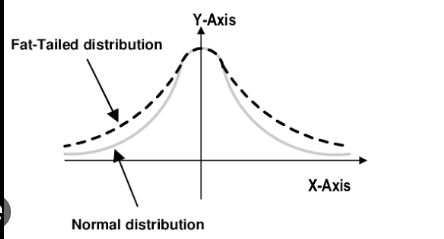

 - ornegin elinde toplamin meani 100 olan bir dagilim var, normal distro der ki bu cok siradisi
 - t-test ise kucuk orneklemde calisiyorsan bu uc degerler normal der. uc degerlere daha fazla tolerans gosterir.

- t-distroda uc degerlerin gorulme olasiligi cok yuksektir
- cunku elimizde az veri var, dolayisiyla hata yapma payimiz da yuksektir.
> Mesela yeni ilac var bir 12 hasta bunun icin z-test yerine t-test kullanilir.

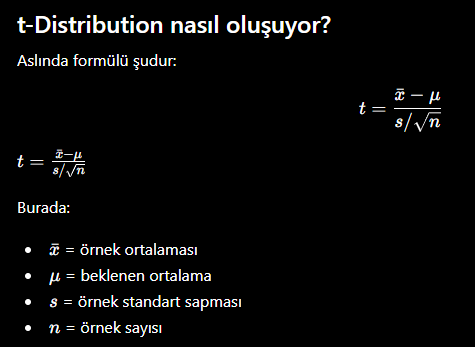
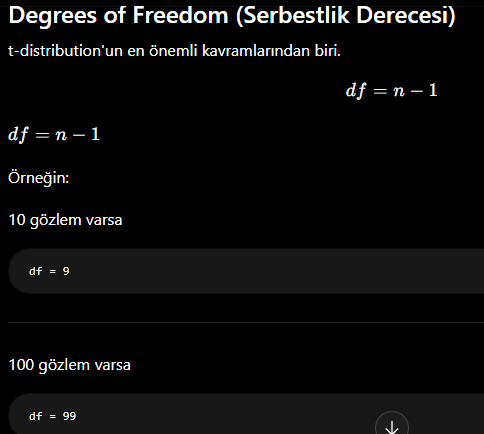


> Degrees of Fredom ya da df  df = n - 1 arttikça normal distroya yaklasilir


- **z-test** toplam std biliniyorsa ve cok buyuk veri varsa
- **t-test** std'yi ornekten tahmin ediyorsan. Gercek hayatta std her zaman bilinmez, dolayisiyla daha cok t-test kullanilir.


- Data Science'ta En Yaygın Kullanım Alanları
- A/B test sonuçlarını karşılaştırma
- İki makine öğrenmesi modelinin performansını kıyaslama
- İlaç deneyleri
- Akademik araştırmalar
- Backend benchmark karşılaştırmaları
- NLP model değerlendirmeleri**

In [ ]:
from scipy.stats import ttest_ind

group_a = [70, 72, 68, 71, 69]
group_b = [80, 81, 79, 82, 78]

t_stat, p_value = ttest_ind(group_b, group_a)

print(t_stat)
print(f"{p_value:.10f}") # ===> sonucta p_value < 0.05. Ve genelde p_valuesine bakilir karar verilirken gercek hayatta. 

# Neden p_val kucuk cikti cunku her grubun icindeki std cok kucuk 70 ve 80. Her grubun yayilimi da ayni oldugu icin p_value kucuk cikti, yani bu iki grubun ayni populasyondan gelmis olmasi
# cok dusuk bir ihtimal. yani ayni olmasi (H0) reddedildi

print(p_value) # ????? =>>> 8.488181527628489e-06 ==> 8.488181527628489×10−6 ===> 8.488181527628489 × 0.000001 = 0.000008488181527628489
# ! H₀'ı reddetmek için yeterli kanıt yoktur. H0 reddedilemedi elimizde H0 curutecek kanit yok. bu soylenis sekili
# H₀ reddedildi → Elimizde aksini gösterecek güçlü kanıt var.
# H₀ reddedilemedi → Elimizde H₀'ı çürütecek yeterli kanıt yok.


# * Hesaplanilisi:
#! Ortalama hesaplama

df = 8  # ==> Degrees of Freedom 

# Mean A = 70
# Mean B = 80

# Adım 2: Standart sapmaları hesapla
# Group A: Veriler: 70 72 68 71 69 =====> Ortalamadan farklar: 0 2 -2 1 -1 Kareleri: 0 4 4 1 1 ===> toplam 10 ==> Bu örnek (sample) olduğu için n-1'e böleriz.
# sample sayisi 5 ==> 5 - 1 = 4 =>>> 10/4 ==> 2.5 sqrt: ==> std: 1.581


# Group B

# Farklar: 0 1 -1 2 -2 ==> kareler: 0 1 1 4 4 ==> toplam: ==> 10 ==> n-1 => 10 / 4 = 2.5 => std sqrt => 1.581 

# !Standard Error => İki ortalamanın farkının standart hatası: SE = math.sqrt((s1**2/5) + (s2**2/5)) 
# SE = math.sqrt(2.5/5 + 2.5/5) = math.sqrt(0.5 + 0.5) = math.sqrt(1) = 1 

#! t-statistic hesapla t = (grup_a_mean - grup_b_mean) / math.sqrt((stdv1**2 / n1) + (stdv2**2) / n2 ) => t = 70 - 80 / 1 = -10


# ! pvalue bulma: t= -10. n1=5, n2=5 oldugu icin degrees of freedom tahmini ==> df = n1+n2 -2 = 8 == ya da df = (n1-1) + (n2-1) = 8 

# ! simdi t-distro tablsona gidiyoruz:
# t = - 10 absolute |t| = 10 tahmini p_val =0.000008 

# t aslında şu soruyu cevaplıyor: İki grup ortalaması, beklenen rastgele değişime göre kaç standart hata uzaklıkta? fark ise 10, standart error ise 1. dolayisiyla 10/1=10
# yani ortalamalar 10 std error kadar uzakta. Eger SE = 8 olsaysi o zaman 10/8 = 1.25 olurdu t. bu durumda p_val = 0.24 olurdu ve H0 reddedilemezdi

# SciPy ne yapıyor?
# from scipy.stats import t  ===> ttest_ind() icinde olan islemler

# t_stat = -10
# df = 8

# p = 2 * t.sf(abs(t_stat), df) =>> survival function => P(T > |t|) sonra iki kuyruk oldugu icin sunu yapiyor => p =  2 * P(T>|t|)

# print(p)


# CDF ile => cumulative distro function P(T≤t)
from scipy.stats import t

cdf = t.cdf(10, df=8)

print(cdf) # ===> 0.99999957
# ama bizim istedigimiz sag kuyruk 1 - 0.99999957 = 0.0000042441 ==> iki kuyruk oldugu icin 2 × 0.0000042441 = 0.0000084882


10.0
0.0000084882
8.488181527628489e-06


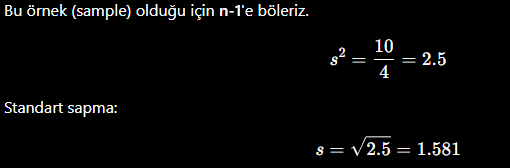

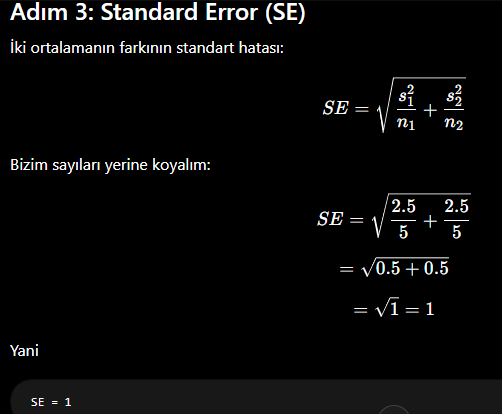


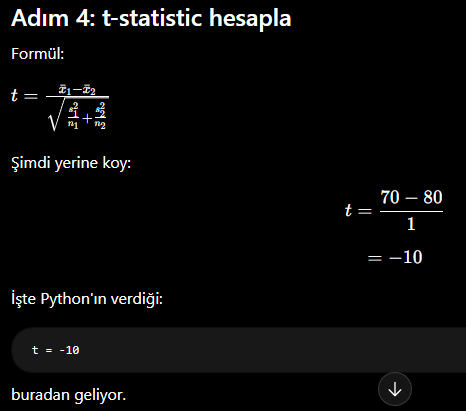

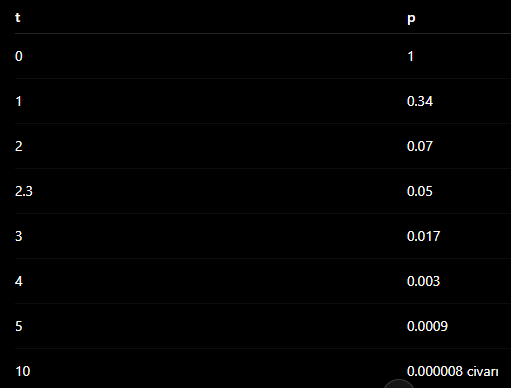

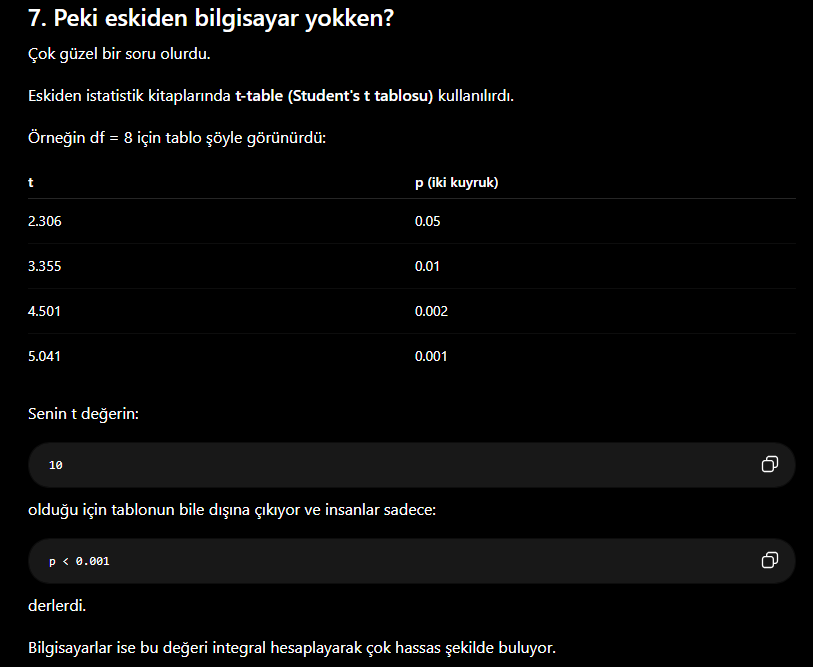

> Madem karar verirken p-value'a bakıyoruz, o zaman t-statistic neden hesaplanıyor?
- cunku p-val t-statistikten hesaplanir
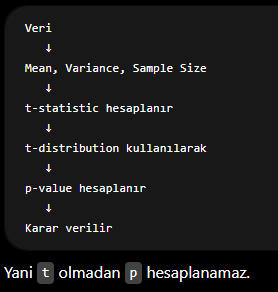

- dolayisiyla hesaplanir ama p-vale bakilir sonuc olarak

In [34]:
import numpy as np
import math
from scipy.stats import t

group_a = np.array([70, 72, 68, 71, 69])
group_b = np.array([80, 81, 79, 82, 78])


mean_a = group_a.mean()
mean_b = group_b.mean()

print(f'mean_a {mean_a}')
print(f'mean_b {mean_b}')

var_a = np.var(group_a, ddof=1) # for sample ddof=1
var_b = np.var(group_b, ddof=1)

std_a = math.sqrt(var_a) # sqrt(2.5) 1.58
std_b = math.sqrt(var_b)

print(f'var_a {var_a}') # 10/(5-1) = 10 / 4 = 2.5
print(f'var_b {var_b}')
print(f'std_a {std_a}')
print(f'std_b {std_b}')

n1 = len(group_a)
n2 = len(group_b)
print(f'len_n1 {n1}')
print(f'len_n2 {n2}')




SE = math.sqrt((std_a ** 2/n1) +(std_b ** 2/n2))
print(f"SE {SE}")


t_score = (mean_a - mean_b) / SE

print(f"t_score { t_score}")


# with CDF or degree of freedom ==> dof 
df = len(group_a) + len(group_b ) - 2
print(f"df { df}")
CDF = t.cdf(x=t_score, df=df)  # ! ==> P(T ≤ -10) ===> one-tailed
print(f"CDF {CDF:.10f}")

two_tailed_cdf = 2 / t.cdf(abs(t_score), df=df)
print(f"two_tailed_cdf {two_tailed_cdf:.10f}")

#with survival function
sf = t.sf(t_score, df=df) # ! P(T > 10) ===> one-tailed 
print(f"sf {sf:.10f}")

two_tailed_sf = 2 * t.sf(abs(t_score), df=df)
print(f"two_tailed_sf {two_tailed_sf:.10f}")

print(f"p_val {p_val:.10f}")

# ! These all what scipy.stats.ttest_ind() do ==> ttest_ind() use two_tailed as a default


# Peki neden ttest_ind() varsayılan olarak two-tailed kullanıyor?

# Çünkü çoğu bilimsel çalışmada araştırmacılar "iki grup arasında herhangi bir fark var mı?" sorusunu sorarlar. Yani yönle değil, farkın varlığıyla ilgilenirler.

# Örneğin:

# Yeni ilaç eski ilaçtan daha iyi mi veya daha kötü mü?
# Yeni eğitim yöntemi eski yöntemden farklı mı?
# Yeni ML modeli eskisinden farklı performans mı gösteriyor?

# Bu nedenle varsayılan yaklaşım iki kuyruğu da dikkate alan two-tailed testtir.


mean_a 70.0
mean_b 80.0
var_a 2.5
var_b 2.5
std_a 1.5811388300841898
std_b 1.5811388300841898
len_n1 5
len_n2 5
SE 1.0
t_score -10.0
df 8
CDF 0.0000042441
two_tailed_cdf 2.0000084882
sf 0.9999957559
two_tailed_sf 0.0000084882
p_val 0.0000000000


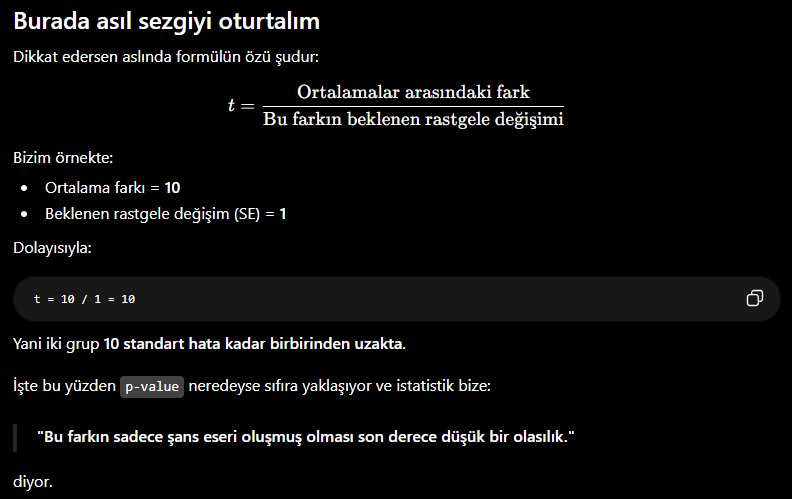

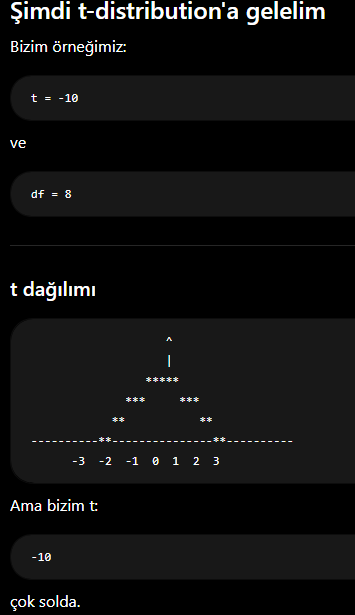
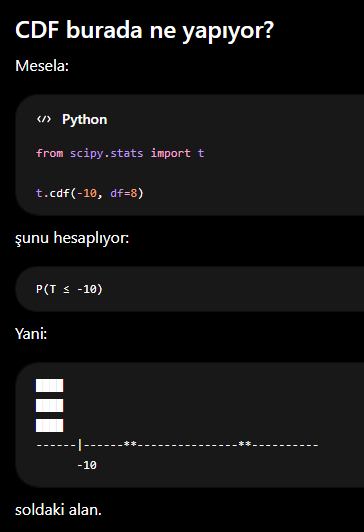
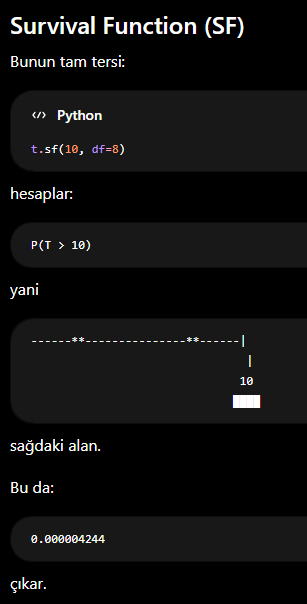

In [ ]:
#One-tailed test
# Tek yönlü hipotez.

# Mesela diyorsun ki: Yeni ilaç eskisinden daha iyidir. Kotu olmasi beni ilgilendirmiyor. o yuzden one-tailed

# P(T > t) == hipotez

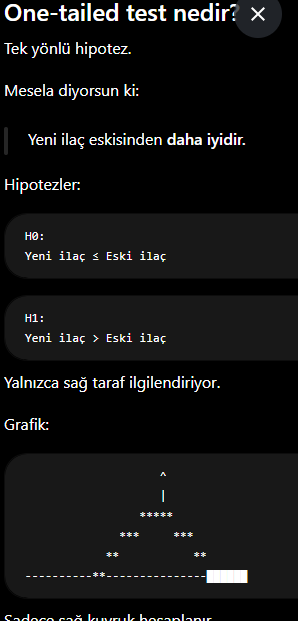
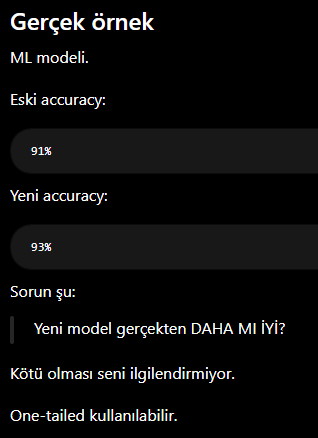

In [ ]:
# Two-tailed test => burada yon onemli degildir ==> fark varmi <== onemli bu

# P(T < -|t|) + P(T > |t|) => 2×P(T>∣t∣)

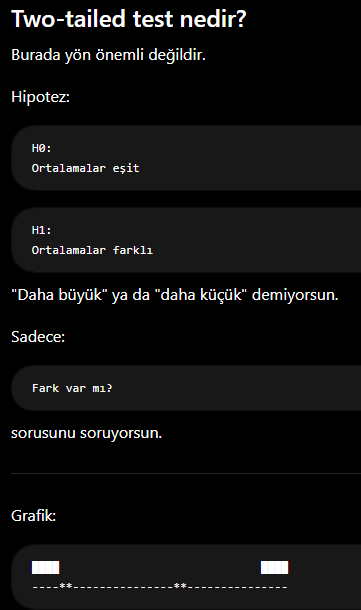
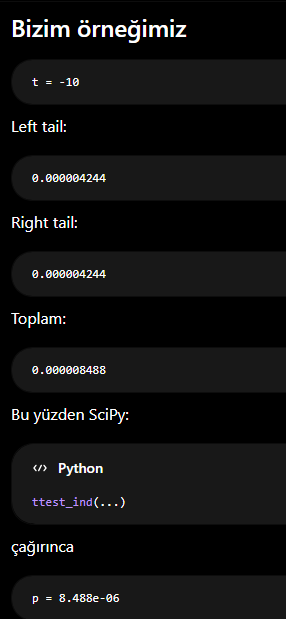

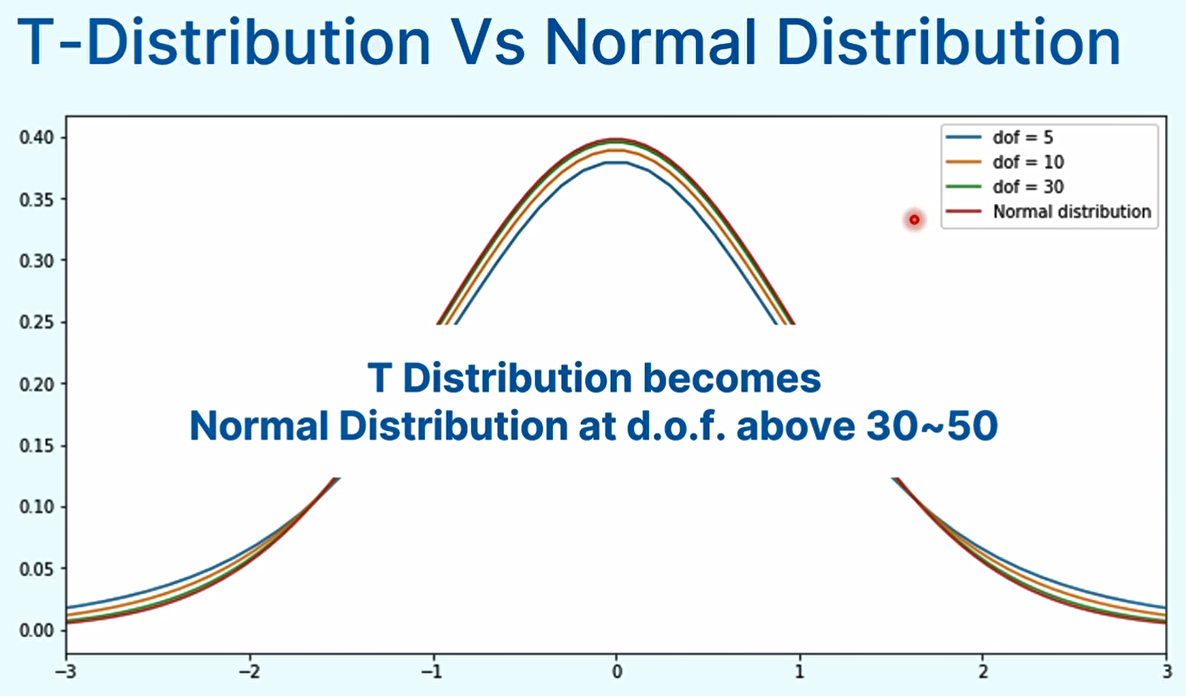

In [36]:
delivery = np.array([528, 566, 589, 495, 583, 598, 545, 566, 578, 688])
delivery.mean()

np.float64(573.6)

In [38]:
delivery.std()

np.float64(48.18547498987636)

In [48]:
import scipy.stats as ss
failure_to_deliver_percentage = (1-ss.t.cdf(x=11.5*60, loc=delivery.mean(), scale=delivery.std(), df=len(delivery)-1))
probability_to_deliver = ss.t.cdf(x=11.5*60, loc=delivery.mean(), scale=delivery.std(), df=len(delivery)-1)
print(failure_to_deliver_percentage)
print(probability_to_deliver)
# 11.5 is border to delivery orders
# len(delivery) - degrees of freedom
# location = delivery.mean()
# scale = delivery.std() 

0.01944302589627689
0.9805569741037231
